# Day 3 - Transformers, Attention & BERT

## From sequential models to modern pretrained Transformers

This notebook is a guided learning workbook. Read each concept, run the demonstration code, pause at the **Think about it** questions, and use the blank **Practice checkpoint** cells to try the idea yourself.

### By the end of this notebook, you should be able to

1. Explain why RNNs, LSTMs and GRUs were important and where they struggle.
2. Explain **attention** in simple language.
3. Understand **Query, Key and Value (Q, K, V)** and the scaled dot-product attention formula.
4. Explain **multi-head attention**, **positional encoding**, **masking**, **residual/skip connections**, **LayerNorm** and the **feed-forward network**.
5. Distinguish **encoder-only**, **decoder-only** and **encoder-decoder** Transformer families.
6. Explain the roles of **BERT, RoBERTa, GPT, T5 and DistilBERT**.
7. Use **Hugging Face Transformers + Datasets**.
8. Fine-tune **BERT for text classification** on a real public dataset.
9. Evaluate a model using **accuracy, precision, recall and F1**.
10. Compare BERT with the **TF-IDF + Logistic Regression baseline from Day 2**.

---

## Your Day 3 learning journey

**Day 1:** How can text be cleaned and represented numerically?

**Day 2:** What NLP problems can be solved using classical ML models?

**Day 3:** How can a model understand **context and relationships between words**, and how can a pretrained language model be adapted to a new task?

> **Memory line:** Sequence models remember -> Attention looks at relationships -> Transformers use attention efficiently -> Pretrained models transfer language knowledge to new tasks.

# 0. Setup

This notebook is designed for **Google Colab with a T4 GPU** or a local environment with PyTorch.

### Colab
Go to:

**Runtime → Change runtime type → T4 GPU**

Then run the setup cells.

> The installation cell may require a runtime restart if Colab already had older versions loaded.

In [1]:
# Run once if these packages are not already installed.
# Current Hugging Face training examples use PyTorch.

%pip install -q -U transformers datasets accelerate scikit-learn bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 94.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 77.2 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


# 1. Bridge from Day 2 - Why do we need something beyond TF-IDF?

On Day 2, you used:

**Text -> TF-IDF -> Logistic Regression -> Class**

That is a strong baseline, but TF-IDF mainly represents **which words/ngrams occur and how important they are**. It does not naturally create a rich contextual meaning for every word.

### Consider the word **bank**

1. **I deposited money in the bank.**
2. **We sat on the river bank.**

The spelling is identical, but the meaning changes because of the surrounding words.

### Think about it

Which nearby words help you understand the meaning of `bank`?

- Sentence 1 gives clues such as `deposited` and `money`.
- Sentence 2 gives the clue `river`.

This leads to a central idea in contextual language models:

> **A word representation should depend on the words around it.**

### Check your understanding

Which statement is more accurate?

**A.** BERT gives the word `bank` exactly the same contextual representation in every sentence.  
**B.** BERT can produce a different contextual representation of `bank` depending on the sentence.

<details>
<summary><b>Reveal answer</b></summary>

**B.** A contextual Transformer representation depends on surrounding tokens.

</details>

# 2. Before Transformers — RNN, LSTM, GRU and Bidirectional RNN

## 2.1 RNN intuition

Imagine reading:

> **The movie was surprisingly very good**

An RNN reads approximately like this:

```text
The → movie → was → surprisingly → very → good
      memory carried forward ───────────────→
```

At each step it combines:

- the **current input**
- the **previous hidden state / memory**

and produces a new hidden state.

### Simple analogy

Think of reading a WhatsApp message **one word at a time** while keeping a small notebook in your hand.

After each word, you update the notebook with what you think is important.

In [3]:
# Tiny RNN shape demonstration
# We are NOT training a useful language model here.
# The goal is only to see how a sequence flows through an RNN.

vocab_size = 100
embedding_dim = 8
hidden_dim = 16

embedding_layer = nn.Embedding(vocab_size, embedding_dim)
rnn = nn.RNN(
    input_size=embedding_dim,
    hidden_size=hidden_dim,
    batch_first=True
)

# One sequence containing 4 token IDs
toy_token_ids = torch.tensor([[10, 20, 30, 40]])

embedded = embedding_layer(toy_token_ids)
rnn_output, final_hidden = rnn(embedded)

print("Token IDs shape:", toy_token_ids.shape)
print("Embedded sequence shape:", embedded.shape)
print("RNN output shape:", rnn_output.shape)
print("Final hidden-state shape:", final_hidden.shape)

Token IDs shape: torch.Size([1, 4])
Embedded sequence shape: torch.Size([1, 4, 8])
RNN output shape: torch.Size([1, 4, 16])
Final hidden-state shape: torch.Size([1, 1, 16])


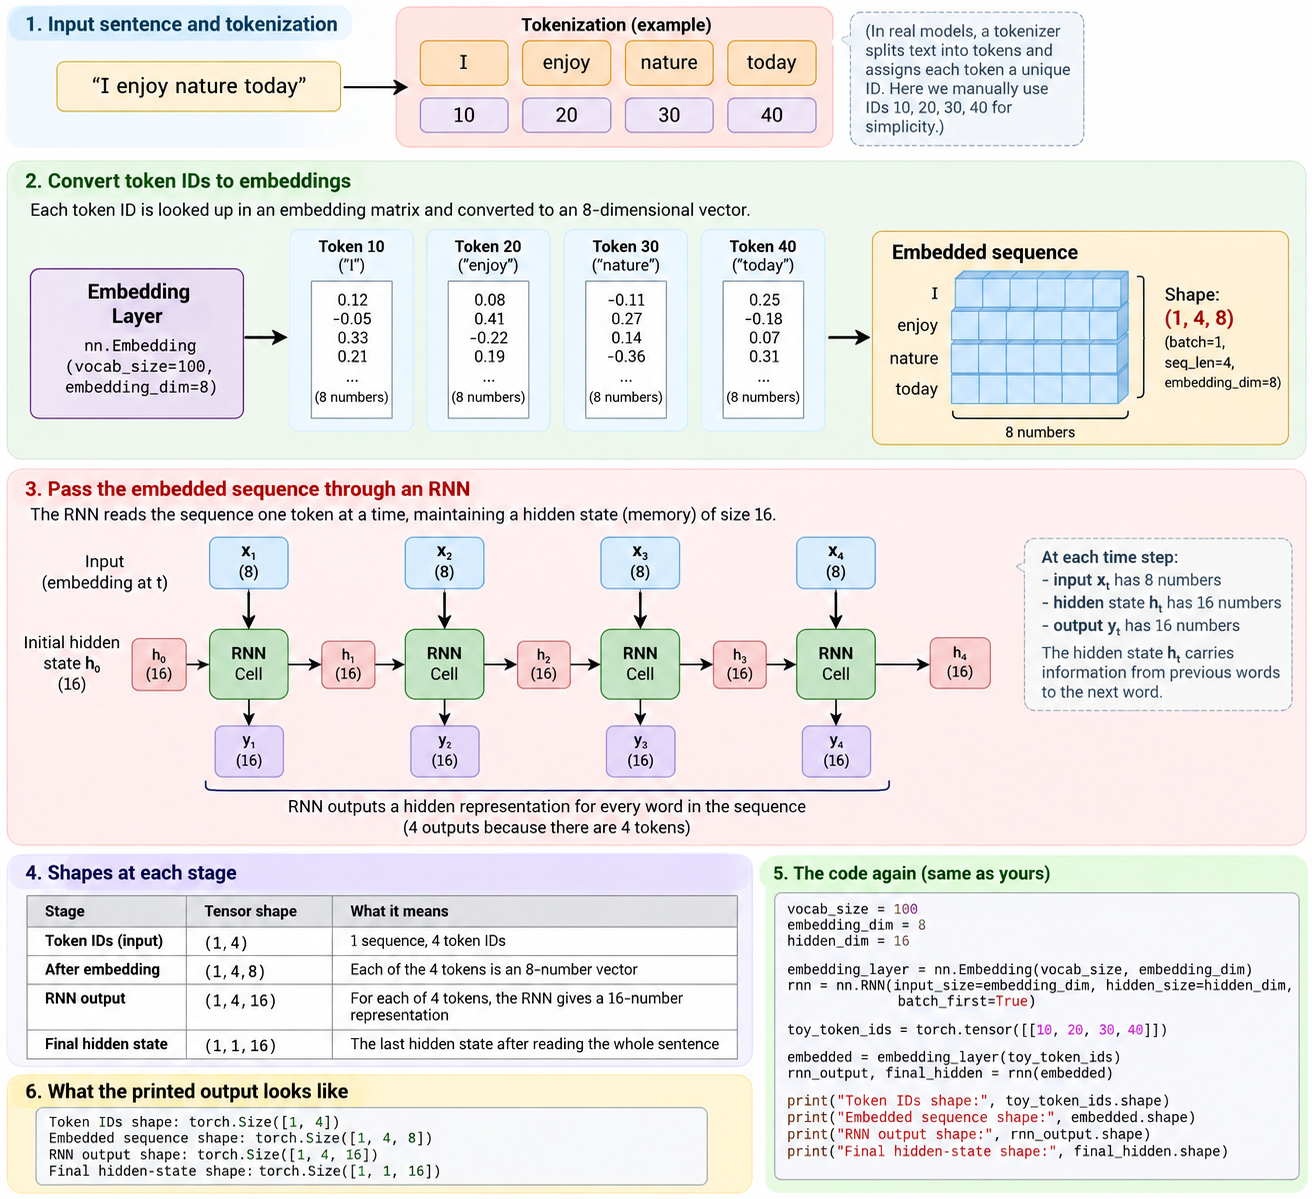

### Practice checkpoint - RNN sequence shape

Change the toy RNN input from **4 tokens to 8 tokens**. Before running the code, predict the new `embedded` and `rnn_output` shapes.

**Hints:**
- Keep the batch size as 1.
- Keep `embedding_dim=8` and `hidden_dim=16`.

Write and run your code in the blank cell below.

In [4]:
# Write your code here

### What do the shapes mean?

If we see:

```text
Embedded sequence: [1, 4, 8]
```

it means:

- `1` sequence in the batch
- `4` tokens
- each token represented by `8` numbers

If the RNN output is:

```text
[1, 4, 16]
```

the RNN produced a `16`-dimensional hidden representation for every token.

---

## 2.2 Why can a plain RNN struggle?

### Problem 1 — Long-term dependency

Consider:

> **The movie that I watched with my family after a very long day was fantastic.**

Information from much earlier in the sequence may need to survive many recurrent steps.

### Problem 2 — Vanishing/exploding gradients

Training requires gradients to travel backward through many time steps.

Repeated multiplication can make gradients:

- extremely small → **vanishing gradient**
- extremely large → **exploding gradient**

### Problem 3 — Sequential computation

Token 2 depends on token 1.  
Token 3 depends on token 2.

That makes RNN computation difficult to parallelize across sequence positions.

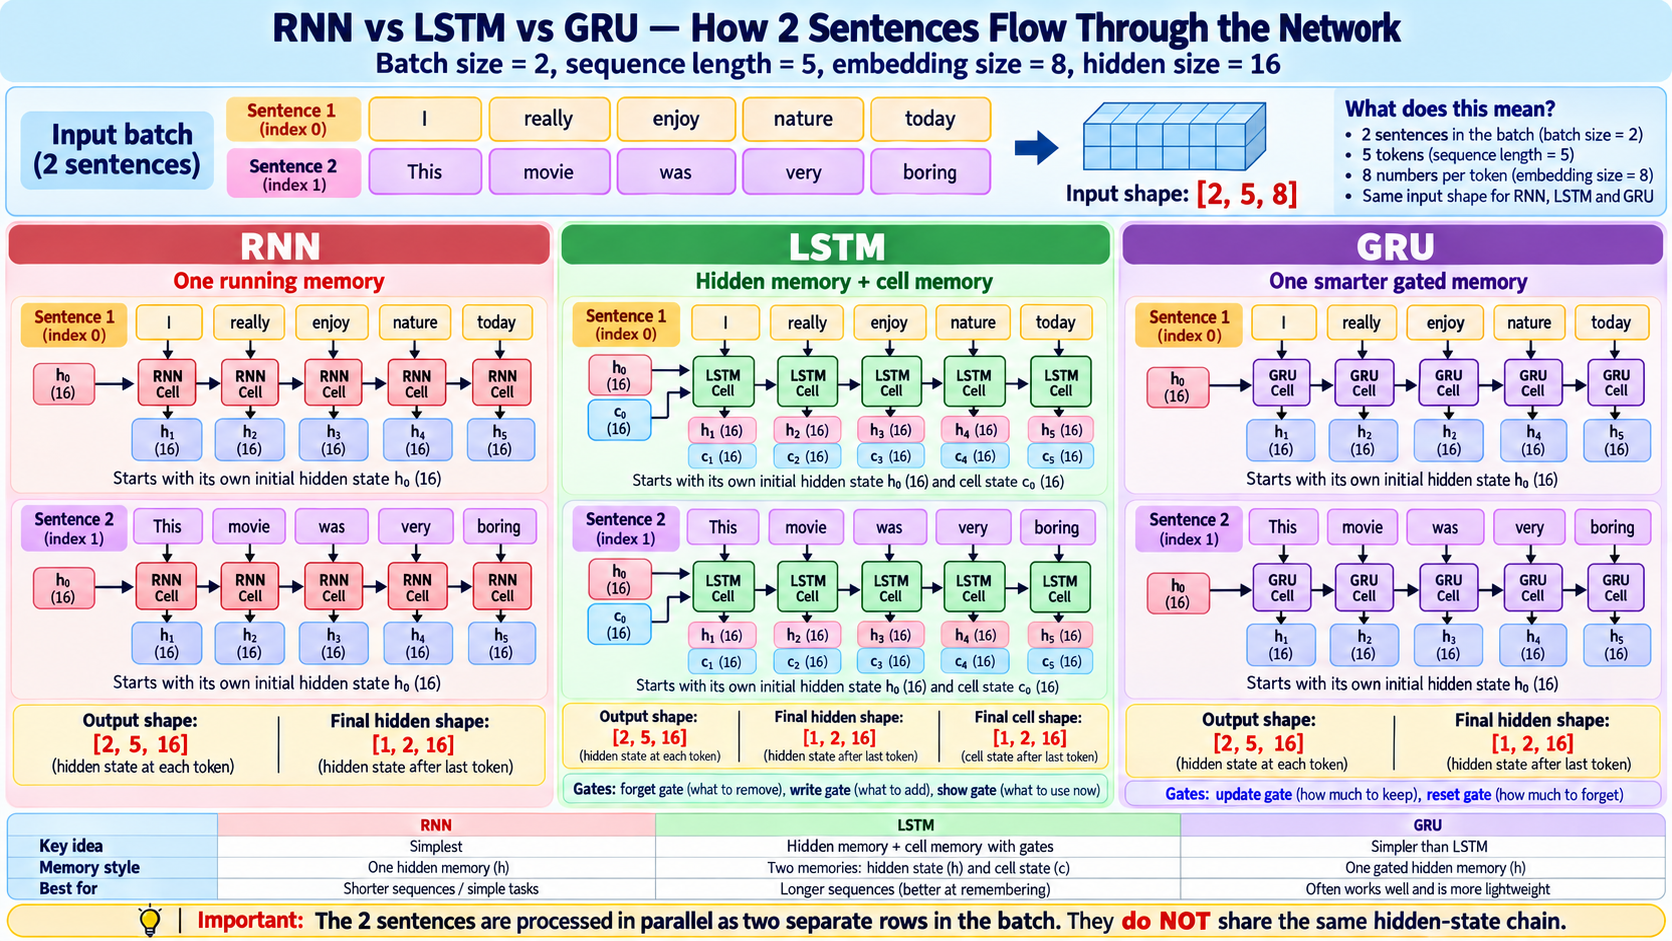

## 2.3 LSTM — give the memory some gates

**LSTM = Long Short-Term Memory**

Instead of relying on one simple hidden-state update, LSTM introduces a **cell state** and gates.

### Three important gates

| Gate | Simple question |
|---|---|
| **Forget gate** | What old information should I throw away? |
| **Input gate** | What new information should I store? |
| **Output gate** | What part of my memory should I expose now? |

### Notebook analogy

Imagine your notebook has three controls:

- **Delete** irrelevant old notes
- **Write** useful new notes
- **Read out** only the notes needed for the current decision

That is much closer to how LSTM manages information.

### LSTM equations — optional mathematical view

For current input \(x_t\) and previous hidden state \(h_{t-1}\):

\[
f_t = \sigma(W_f[h_{t-1},x_t] + b_f)
\]

\[
i_t = \sigma(W_i[h_{t-1},x_t] + b_i)
\]

\[
o_t = \sigma(W_o[h_{t-1},x_t] + b_o)
\]

Where:

- \(f_t\) = forget gate
- \(i_t\) = input gate
- \(o_t\) = output gate
- \(\sigma\) = sigmoid, producing values between 0 and 1

### Interpretation

A gate value close to:

- **0** → block / forget
- **1** → allow / keep

In [5]:
# Compare RNN, LSTM and GRU output shapes

x = torch.randn(2, 5, 8)  # batch=2, sequence length=5, input size=8

rnn = nn.RNN(8, 16, batch_first=True)
lstm = nn.LSTM(8, 16, batch_first=True)
gru = nn.GRU(8, 16, batch_first=True)

rnn_out, rnn_h = rnn(x)
lstm_out, (lstm_h, lstm_c) = lstm(x)
gru_out, gru_h = gru(x)

print("RNN output :", rnn_out.shape)
print("LSTM output:", lstm_out.shape)
print("GRU output :", gru_out.shape)

print("\nLSTM hidden state:", lstm_h.shape)
print("LSTM cell state  :", lstm_c.shape)

RNN output : torch.Size([2, 5, 16])
LSTM output: torch.Size([2, 5, 16])
GRU output : torch.Size([2, 5, 16])

LSTM hidden state: torch.Size([1, 2, 16])
LSTM cell state  : torch.Size([1, 2, 16])


### Practice checkpoint - LSTM hidden state and cell state

Use the existing LSTM example. Print `lstm_h.shape` and `lstm_c.shape`, then add comments explaining what each dimension represents.

**Hints:**
- The first dimension is related to layers/directions.
- The remaining dimensions represent batch size and hidden size.

Write and run your code in the blank cell below.

In [6]:
# Write your code here

## 2.4 GRU

**GRU = Gated Recurrent Unit**

GRU is another gated recurrent architecture.

It is generally simpler than LSTM and mainly uses:

- **update gate**
- **reset gate**

### Very simple comparison

```text
RNN  → simplest recurrent memory
LSTM → richer memory + forget/input/output gates
GRU  → simpler gated alternative to LSTM
```

There is no universal rule that one is always best.

The right choice depends on the task, data, compute and architecture.

## 2.5 Bidirectional RNN

A normal left-to-right RNN sees:

```text
The → bank → is → near → the → river
```

A bidirectional RNN processes information in both directions:

```text
Forward : The → bank → is → near → the → river
Backward: The ← bank ← is ← near ← the ← river
```

So the representation of `bank` can use information from:

- words before it
- words after it

### Think about it

Why is the word `river` useful for understanding `bank` even though it appears later?

That is one reason **bidirectional context** became important for language understanding.

## 2.6 RNN-family recap

| Model | Memory idea | Main benefit | Main limitation |
|---|---|---|---|
| RNN | Recurrent hidden state | Simple sequence modeling | Long dependencies / sequential |
| LSTM | Cell state + gates | Better long-range memory | More computation / still sequential |
| GRU | Simpler gates | Fewer gates than LSTM | Still sequential |
| BiRNN | Reads both directions | Left + right context | Still recurrent / less parallel |

### Think before moving on

If recurrence forces tokens to be processed sequentially, is there a way for a model to directly ask:

> **For this word, which other words in the sentence matter most?**

That question leads to **attention**.

# 3. Why Attention?

## 3.1 Translation challenge

Consider:

> **English:** I enjoy nature.  
> **Hindi:** मैं प्रकृति का आनंद लेती हूँ।

The order is not a simple one-to-one copy.

To generate a word in the output, a translation model should be able to look back at the relevant input words.

### Sequential encoder-decoder intuition

A traditional encoder can compress the input sequence into a limited representation.

The decoder then tries to generate the translation from that representation.

For long sentences, asking one fixed representation to carry **everything** is difficult.

### Attention changes the question

Instead of:

> “Can one memory vector summarize the whole sentence?”

the model asks:

> “When generating or representing this token, **which input tokens should receive more importance right now?**”

### Key idea

Attention produces **weights**.

For one token, another token may get:

```text
0.02 attention
0.10 attention
0.75 attention
...
```

Higher weight means:

> “Use more information from this token when building the current representation.”

---

### Did you know?

The same word can attend differently depending on the sentence.

That is one reason Transformer representations are called **contextual**.

# 4. Self-Attention and Q, K, V

## 4.1 A simple analogy

Imagine searching a digital library.

### Query (Q)
**What am I looking for?**

> “I need information related to rivers.”

### Key (K)
**What does each item advertise that it contains?**

> “finance”, “river geography”, “sports”, ...

### Value (V)
**What useful information does the item actually provide?**

The model:

1. compares **Query with Keys**
2. gets relevance scores
3. converts them into attention weights
4. takes a weighted combination of the **Values**

---

## 4.2 In a Transformer

Every input token embedding is projected through learned matrices:

\[
Q = XW_Q
\]

\[
K = XW_K
\]

\[
V = XW_V
\]

The matrices \(W_Q\), \(W_K\) and \(W_V\) are learned during training.

So one token generates:

```text
Embedding
   ├──> Query vector
   ├──> Key vector
   └──> Value vector
```

## 4.3 Scaled dot-product attention

The central formula is:

\[
\text{Attention}(Q,K,V)
=
\text{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
\]

Read it from left to right:

### Step 1 — \(QK^T\)
Compare each query with every key.

### Step 2 — divide by \(\sqrt{d_k}\)
Scale the scores so that large vector dimensions do not make dot products excessively large.

### Step 3 — softmax
Convert scores into positive weights that sum to 1.

### Step 4 — multiply by \(V\)
Use the attention weights to combine the useful information carried by the values.

### Read one row like this

If the row for `enjoy` were:

```text
I        0.15
enjoy    0.25
nature   0.60
```

we could say:

> While creating the contextual representation for `enjoy`, this head is using more information from `nature`.

Do **not** assume every learned attention head has a clean human-readable role. The visualization is useful, but attention weights are not automatically a complete causal explanation of a model prediction.

# 5. Multi-Head Attention

One attention calculation gives us one way of comparing tokens.

A Transformer instead uses **multiple attention heads**.

### Simple analogy

Imagine several people reading the same sentence with different lenses:

- one may focus on nearby words
- another may focus on subject–verb relationships
- another may react strongly to negation
- another may connect distant references

The model learns these patterns; we should not assume a fixed human label for every head.

---

## Why multiple heads?

Different heads can learn different projections of Q, K and V.

Then their outputs are concatenated and projected again.

\[
\text{MultiHead}(Q,K,V)
=
\text{Concat}(\text{head}_1,\ldots,\text{head}_h)W_O
\]

### Dimension example

Original Transformer base:

```text
d_model = 512
heads   = 8
512 / 8 = 64 dimensions per head
```

BERT-base:

```text
hidden size = 768
heads       = 12
768 / 12   = 64 dimensions per head
```

### Important correction

**Multi-head** attention is mainly about learning multiple attention subspaces.

The Transformer's **self-attention architecture** also allows token computations to be parallelized far more effectively than a recurrent RNN.

### Think about it

Suppose one attention head strongly connects:

```text
bank -> river
```

while another focuses more on:

```text
bank -> near
```

Why might combining both views be more useful than relying on only one attention pattern?

# 6. Positional Encoding — How does the Transformer know word order?

Self-attention can examine tokens in parallel.

But without additional position information, the model needs help distinguishing order.

Compare:

> **Dog bites man**

and

> **Man bites dog**

The words are almost the same.

The meaning is very different because the positions changed.

### Transformer solution

Add a **position representation** to the token embedding:

\[
\text{Final input}
=
\text{Token embedding}
+
\text{Positional encoding}
\]

In the original Transformer, fixed sine/cosine positional encodings were used.

## 6.1 Original sinusoidal formula

For token position \(pos\) and embedding dimension index \(i\):

\[
PE(pos, 2i)
=
\sin
\left(
\frac{pos}{10000^{2i/d_{model}}}
\right)
\]

\[
PE(pos, 2i+1)
=
\cos
\left(
\frac{pos}{10000^{2i/d_{model}}}
\right)
\]

### Layman interpretation

Each position gets a numerical **address pattern**.

Different embedding dimensions oscillate at different frequencies.

The model can use these patterns to reason about:

- position
- relative distance
- order

Modern Transformer families may use other positional methods, but the sine/cosine formulation is the classic starting point.

# 7. Transformer Architecture

The original Transformer was introduced for sequence-to-sequence tasks such as machine translation.

The **original base architecture** used:

- **6 encoder layers**
- **6 decoder layers**
- \(d_{model}=512\)
- **8 attention heads**

> Important: **6 encoder + 6 decoder layers describes the original Transformer configuration. It is not a rule that every Transformer must use 6 + 6.**

---

## 7.1 Big picture

```text
SOURCE SENTENCE
      ↓
Token Embedding + Position
      ↓
┌──────────────────────┐
│      ENCODER         │
│ Self-Attention       │
│ Add & Norm           │
│ Feed Forward         │
│ Add & Norm           │
└──────────────────────┘
      ↓
Context from source
      ↓
┌──────────────────────┐
│      DECODER         │
│ Masked Self-Attn     │
│ Add & Norm           │
│ Cross-Attention      │
│ Add & Norm           │
│ Feed Forward         │
│ Add & Norm           │
└──────────────────────┘
      ↓
Linear layer
      ↓
Softmax over vocabulary
      ↓
NEXT OUTPUT TOKEN
```

## 7.2 Encoder block

A simplified encoder layer:

```text
Input
  ↓
Multi-Head Self-Attention
  ↓
Residual Add + LayerNorm
  ↓
Feed-Forward Network
  ↓
Residual Add + LayerNorm
  ↓
Output
```

The output of one encoder layer becomes the input to the next encoder layer.

## 7.3 Decoder block

A simplified decoder layer:

```text
Previous output tokens
  ↓
Masked Multi-Head Self-Attention
  ↓
Add + Norm
  ↓
Cross-Attention over encoder output
  ↓
Add + Norm
  ↓
Feed-Forward Network
  ↓
Add + Norm
```

### Two different attention jobs happen in a decoder

1. **Masked self-attention**  
   Look only at already-available output tokens.

2. **Cross-attention**  
   Look at information produced by the encoder.

# 8. Masking — Preventing the decoder from cheating

Suppose the correct output is:

```text
I love nature
```

While learning to predict `love`, the decoder should not be allowed to peek at the future word `nature`.

A **causal mask** blocks future positions.

Conceptually:

```text
             Key position
             1   2   3   4
Query 1      ✓   ✗   ✗   ✗
Query 2      ✓   ✓   ✗   ✗
Query 3      ✓   ✓   ✓   ✗
Query 4      ✓   ✓   ✓   ✓
```

This is crucial for decoder-only autoregressive models such as GPT.

### Check your understanding

Why does BERT not use the same left-to-right causal mask for normal encoder self-attention?

<details>
<summary><b>Reveal answer</b></summary>

BERT is designed to build **bidirectional contextual representations**. A token can normally use information from both its left and right context.

</details>

# 9. Add & Norm — Residual Connections + Layer Normalization

## 9.1 Residual / skip connection

Instead of using only:

\[
F(x)
\]

we add the original input back:

\[
y = x + F(x)
\]

### Simple analogy

Imagine a complicated road through a city.

A residual connection creates a **bypass road**.

Information — and importantly gradients during training — has a more direct route through a deep network.

Residual connections became famous through **ResNet / residual networks** and are a central optimization idea in deep learning.

### Why useful?

They can:

- improve gradient flow
- make very deep networks easier to optimize
- preserve useful input information

They help with vanishing-gradient problems, but should not be described as a magical guarantee that all gradient problems disappear.

## 9.2 Layer Normalization

LayerNorm normalizes the **activations/features of a token representation**.

It does **not** mean “normalize the model weights”.

For a token vector, conceptually:

\[
\text{LayerNorm}(x)
=
\gamma
\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}
+
\beta
\]

where:

- \(\mu\) = mean of the features
- \(\sigma^2\) = variance
- \(\gamma,\beta\) = learned scale and shift parameters

### Why?

It helps stabilize hidden-state distributions and training.

# 10. Feed-Forward Network (FFN)

After attention mixes information **between tokens**, the FFN processes each token representation independently.

A classic Transformer FFN is:

\[
FFN(x)=W_2\,\sigma(W_1x+b_1)+b_2
\]

In the original Transformer base model:

```text
512 → 2048 → 512
```

### Intuition

- Attention asks: **Which other tokens matter to me?**
- FFN asks: **Now that I have contextual information, how should I transform my own representation?**

### Important correction

A feed-forward network is a neural-network building block.

It is **not specific to TensorFlow**.

It can be implemented in PyTorch, TensorFlow/Keras, JAX, NumPy, etc.

# 11. Softmax appears in more than one place

We already used softmax in attention:

\[
softmax(QK^T/\sqrt{d_k})
\]

There it converts relevance scores into **attention weights**.

Softmax is also commonly used at an output layer for **multi-class probabilities**.

Example logits:

```text
Sports    2.4
Business  0.9
World     1.2
Sci/Tech  3.1
```

Softmax turns them into probabilities that sum to 1.

So:

> **Softmax is not only a classification concept. It is also part of attention.**

# 12. Transformer families — BERT, RoBERTa, GPT, T5

A very useful way to remember modern NLP models is by asking:

> **Which part of the Transformer do they mainly use?**

| Model family | Architecture style | Context / training idea | Typical strengths |
|---|---|---|---|
| **BERT** | Encoder-only | Bidirectional masked-language modeling; original BERT also used NSP | Classification, NER, extractive QA, embeddings |
| **RoBERTa** | Encoder-only | BERT-style encoder with revised pretraining | Strong language understanding |
| **GPT** | Decoder-only | Causal / next-token prediction | Text generation |
| **T5** | Encoder-decoder | Text-to-text; span-corruption pretraining | Translation, summarization, QA, generation |
| **DistilBERT** | Smaller encoder-only BERT family | Knowledge distillation | Faster/lighter classification and understanding |

### Memory trick

```text
BERT → Understand
GPT  → Generate
T5   → Input text → Output text
```

This is intentionally simplified; all of these families can be adapted to many tasks.

## 12.1 BERT

**BERT = Bidirectional Encoder Representations from Transformers**

BERT uses a stack of Transformer **encoders**.

### BERT-base

```text
12 encoder layers
hidden size = 768
12 attention heads
~110M parameters
```

### BERT-large

```text
24 encoder layers
hidden size = 1024
16 attention heads
~340M parameters
```

### Why “bidirectional”?

Consider:

> **The bank is on the river.**

When building the representation of `bank`, BERT can use:

- left context: `The`
- right context: `is on the river`

That helps it distinguish a river bank from a financial bank.

## 12.2 Original BERT pretraining objectives

### 1. Masked Language Modeling (MLM)

Hide some tokens and predict them using surrounding context.

```text
The [MASK] is on the river.
          ↓
        bank
```

### 2. Next Sentence Prediction (NSP)

Original BERT also learned a binary task asking whether Sentence B naturally followed Sentence A.

### Pretraining → fine-tuning

```text
Huge unlabeled text
      ↓
Pretrain BERT
      ↓
General language representations
      ↓
Add small task-specific head
      ↓
Fine-tune on labeled business/task data
```

## 12.3 RoBERTa

**RoBERTa = Robustly Optimized BERT Pretraining Approach**

The architecture is BERT-like, but the pretraining recipe changed.

Key ideas commonly associated with RoBERTa include:

- dynamic masking
- removal of NSP
- more training data
- larger batches / longer training
- byte-level BPE tokenization

### Main lesson

RoBERTa showed that **how we pretrain** can matter enormously — not only the basic architecture.

## 12.4 GPT

GPT-style models are primarily **decoder-only** Transformers.

They use causal attention:

```text
I      → can see: I
I love → can see: I, love
I love NLP → can see: I, love, NLP
```

The model repeatedly learns:

> **Given everything so far, what token comes next?**

That objective naturally supports text generation.

## 12.5 T5

**T5 = Text-to-Text Transfer Transformer**

T5 is an **encoder-decoder** model.

Its key idea is to express many NLP tasks as:

```text
TEXT INPUT → TEXT OUTPUT
```

Examples:

```text
translate English to German: I love NLP
→ Ich liebe NLP

summarize: <long document>
→ <short summary>

question: ... context: ...
→ answer text
```

That creates a unified text-to-text framework.

### Check your understanding - match the model family to the task

Match each task with a natural architecture choice:

1. **Sentiment classification**
2. **Generate the next paragraph**
3. **Translate English -> French**
4. **Named Entity Recognition**

<details>
<summary><b>Reveal a reasonable mapping</b></summary>

- BERT/RoBERTa are natural encoder choices for 1 and 4.
- GPT-style causal decoders are natural for 2.
- Encoder-decoder models such as T5 are natural for 3.

These are useful architecture-task matches, not rigid rules.

</details>

# 13. Common misconceptions to avoid

| Easy oversimplification | More accurate understanding |
|---|---|
| “Every Transformer has 6 encoders and 6 decoders.” | The **original Transformer base** used 6 + 6. Modern models vary widely. |
| “BERT is the encoder and GPT is the decoder of the same model.” | BERT is an **encoder-only family**; GPT is a **decoder-only family**. They are separate pretrained architectures. |
| “Multi-head attention exists mainly to parallelize.” | Multiple heads learn different projections/relationships. The **self-attention architecture** also enables strong parallelism across tokens. |
| “Normalization normalizes model weights.” | Transformer LayerNorm normalizes **hidden activations/features**, then learns scale and shift parameters. |
| “FFN means TensorFlow neural network.” | A feed-forward network is an architecture concept and can be implemented in PyTorch, TensorFlow/Keras, JAX, etc. |
| “Skip connections completely solve vanishing gradients.” | Residual connections improve gradient flow and optimization, but they are not a universal cure. |
| “Attention tells us exactly why the model predicted something.” | Attention weights are informative, but are not automatically a complete causal explanation. |

# 14. Hugging Face — What is it?

Think of Hugging Face as an ecosystem that makes pretrained AI models easier to **find, load, tokenize, train and share**.

For today's lab we mainly use:

### `transformers`
Model architectures, tokenizers, pretrained checkpoints and training utilities.

### `datasets`
Convenient access to public datasets.

### Hugging Face Hub
Repository of pretrained models, datasets and related artifacts.

### `Trainer`
A PyTorch training/evaluation loop for supported Transformer models.

---

## Basic workflow

```text
Raw text
   ↓
AutoTokenizer
   ↓
input_ids + attention_mask
   ↓
AutoModelForSequenceClassification
   ↓
logits
   ↓
class prediction
```

## 14.1 PyTorch vs TensorFlow vs Keras

### PyTorch
A deep-learning framework built around tensors, automatic differentiation and neural-network modules.

Typical objects:

```python
torch.Tensor
torch.nn.Module
torch.optim
DataLoader
```

### TensorFlow
Another major deep-learning framework with tensor operations, automatic differentiation, training and deployment tooling.

### Keras
A high-level deep-learning API.

Modern **Keras 3** can run on multiple backends, including TensorFlow, PyTorch and JAX. `tf.keras` also remains a familiar TensorFlow-facing API in existing codebases.

### For this notebook
We use **PyTorch**, because the current Hugging Face `Trainer` workflow is PyTorch-focused.

The concepts — embeddings, attention, layers, loss, gradient descent — are not tied to one framework.

# 15. Transformer tokenization — words are often split into subwords

Classical NLP often starts with word tokens.

Transformer tokenizers frequently use **subword tokens**.

Why?

Because a fixed vocabulary cannot contain every possible:

- word
- spelling variation
- name
- technical term

Subword tokenization lets the model reuse smaller pieces.

Example idea:

```text
unbelievable
→ un + believe + able
```

The exact pieces depend on the tokenizer.

In [7]:
# Import AutoTokenizer from Hugging Face Transformers.
# AutoTokenizer automatically loads the correct tokenizer
# based on the pretrained model checkpoint we provide.
from transformers import AutoTokenizer


# Name of the pretrained BERT model we want to use.
# "bert-base-uncased" means:
# - BERT base architecture
# - English text is converted to lowercase before tokenization
bert_checkpoint = "google-bert/bert-base-uncased"


# Load the tokenizer that was originally trained with this BERT model.
# It contains BERT's vocabulary and WordPiece tokenization rules.
bert_tokenizer = AutoTokenizer.from_pretrained(bert_checkpoint)


# Example sentence that we want to tokenize.
sample_sentence = "Transformers are unbelievably useful for NLP."


# Break the sentence into BERT WordPiece tokens.
# A word may remain as one token or may be split into smaller subword pieces.
#
# Example:
# "unbelievably" may become something like:
# ["un", "##bel", "##ie", ...]
#
# The ## symbol indicates that the token is a continuation
# of the previous subword.
bert_tokens = bert_tokenizer.tokenize(sample_sentence)


# Convert each token into its corresponding integer ID
# from BERT's fixed vocabulary.
#
# Conceptually:
# "transformers" → token ID
# "are"          → token ID
# ...
#
# These IDs are what the model actually receives before
# looking up the corresponding embedding vectors.
bert_ids = bert_tokenizer.convert_tokens_to_ids(bert_tokens)


# Create a small table so we can clearly see:
# 1. each token created by the tokenizer
# 2. the vocabulary ID assigned to that token
display(pd.DataFrame({
    "token": bert_tokens,
    "token_id": bert_ids
}))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,token,token_id
0,transformers,19081
1,are,2024
2,un,4895
3,##bel,8671
4,##ie,2666
5,##va,3567
6,##bly,6321
7,useful,6179
8,for,2005
9,nl,17953


### Practice checkpoint - Explore WordPiece tokenization

Choose a technical or unusually long word of your own and use the BERT tokenizer to see whether it is split into multiple subword tokens.

**Hints:**
- Try words such as `microservices`, `electrification`, or another term you are curious about.

Write and run your code in the blank cell below.

In [8]:
# Write your code here

### What does `uncased` mean?

`bert-base-uncased` lowercases text as part of its tokenization behavior.

So:

```text
Apple
APPLE
apple
```

are generally normalized toward the same lowercase form before WordPiece tokenization.

This is a model/tokenizer design choice, not a rule for all Transformers.

# 16. Lab 4 — Fine-tune BERT for Text Classification

## Real-world public dataset: SST-2

You will use **SST-2**, a standard sentiment-classification dataset distributed through GLUE.

Task:

```text
Sentence → NEGATIVE / POSITIVE
```

Examples conceptually:

```text
"A beautifully acted film." → Positive

"A dull and predictable movie." → Negative
```

### Why this lab is important

On Day 2 we engineered TF-IDF features.

Today the workflow changes:

```text
Text
 ↓
BERT tokenizer
 ↓
Pretrained contextual encoder
 ↓
Classification head
 ↓
Fine-tune all/most model parameters for our labels
```

In [9]:
# Import the Hugging Face function used to download/load datasets.
from datasets import load_dataset


# Load the SST-2 sentiment dataset from the GLUE benchmark.
#
# "nyu-mll/glue" = dataset repository
# "sst2"          = the specific GLUE task we want
#
# SST-2 contains movie-review sentences with sentiment labels:
# 0 = Negative
# 1 = Positive
sst2 = load_dataset("nyu-mll/glue", "sst2")


# Print the complete dataset structure.
# This helps us see the available splits such as:
# - train
# - validation
# - test
#
# It also shows the number of rows and column names.
print(sst2)


# Print a heading so the next output is easier to understand.
print("\nTraining example:")


# Access the first example from the training split.
#
# sst2["train"]    → training dataset
# [0]              → first row/example
#
# The output will contain fields such as:
# sentence → the review text
# label    → sentiment class
# idx      → row/example identifier
print(sst2["train"][0])

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

Training example:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


## 16.1 Choose a dataset size that fits your runtime

Full BERT fine-tuning can take time. The switch below uses a smaller sample so you can learn the full workflow without waiting for the entire training split.

Set:

```python
FAST_DEMO = False
```

when you want to train on the full training split.

In [10]:
# FAST_DEMO is used to control whether we train on:
# - a smaller subset of the dataset for faster classroom execution, or
# - the complete dataset.
FAST_DEMO = True


# If FAST_DEMO is True, take only a smaller sample
# from the original training and validation datasets.
if FAST_DEMO:

    # Take the training split.
    # shuffle(seed=SEED) randomly rearranges the rows,
    # but using the same SEED makes the shuffle reproducible.
    #
    # select(...) then keeps only the first 8,000 rows
    # after shuffling.
    #
    # min(...) is used so that we do not request more rows
    # than are actually available in the dataset.
    train_ds = sst2["train"].shuffle(seed=SEED).select(
        range(min(8000, len(sst2["train"])))
    )

    # Do the same for the validation split.
    # Here we keep at most 1,000 validation examples.
    val_ds = sst2["validation"].shuffle(seed=SEED).select(
        range(min(1000, len(sst2["validation"])))
    )


# If FAST_DEMO is False,
# use the complete training and validation datasets.
else:
    train_ds = sst2["train"]
    val_ds = sst2["validation"]


# Print the final number of training examples
# that will actually be used by the model.
print("Train size:", len(train_ds))


# Print the final number of validation examples
# that will be used to evaluate the model.
print("Validation size:", len(val_ds))

Train size: 8000
Validation size: 872


## 16.2 Tokenize with `AutoTokenizer`

BERT does not receive raw strings directly.

The tokenizer creates inputs such as:

- `input_ids`
- `attention_mask`

### `input_ids`
Numerical token IDs from the tokenizer vocabulary.

### `attention_mask`
Usually:

```text
1 → real token
0 → padding token
```

This **padding attention mask** is different from the decoder's causal future mask.

In [11]:
# Import AutoTokenizer from Hugging Face Transformers.
# It automatically loads the tokenizer that matches
# the pretrained model checkpoint we specify.
from transformers import AutoTokenizer


# Specify the pretrained BERT model we want to use.
#
# "bert-base-uncased" means:
# - BERT base architecture
# - text is converted to lowercase during tokenization
MODEL_CHECKPOINT = "google-bert/bert-base-uncased"


# Load the tokenizer that was trained with this BERT checkpoint.
#
# This tokenizer knows:
# - BERT's vocabulary
# - WordPiece tokenization rules
# - how to convert tokens into token IDs
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)


# Create a function that will tokenize a batch of sentences.
#
# The input "batch" will contain multiple examples
# because later we use batched=True.
def tokenize_batch(batch):

    # Take the "sentence" column from the batch
    # and convert the text into BERT-compatible numerical inputs.
    return tokenizer(
        batch["sentence"],

        # If a sentence is longer than max_length,
        # cut the extra tokens.
        truncation=True,

        # Keep at most 128 tokens per sentence.
        max_length=128
    )


# Apply the tokenization function to the training dataset.
#
# .map(...) applies tokenize_batch to the dataset.
#
# batched=True means several sentences are sent
# to tokenize_batch together instead of one at a time.
tokenized_train = train_ds.map(
    tokenize_batch,
    batched=True,

    # After tokenization, remove the original raw-text column
    # and the dataset row identifier.
    #
    # We keep the generated model inputs such as:
    # - input_ids
    # - attention_mask
    # - label
    remove_columns=["sentence", "idx"]
)


# Apply exactly the same tokenization process
# to the validation dataset.
tokenized_val = val_ds.map(
    tokenize_batch,
    batched=True,
    remove_columns=["sentence", "idx"]
)


# Display the first tokenized training example.
#
# The output will typically look like:
#
# {
#   "label": 0 or 1,
#   "input_ids": [...],
#   "attention_mask": [...]
# }
#
# input_ids:
# numerical IDs representing BERT tokens
#
# attention_mask:
# tells BERT which positions contain real tokens
print(tokenized_train[0])
print(train_ds[0])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

{'label': 1, 'input_ids': [101, 12555, 1010, 11951, 1999, 22092, 2066, 2137, 11345, 1998, 2757, 1011, 2006, 1999, 2602, 1010, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
{'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1, 'idx': 32326}


## 16.3 Dynamic padding + DataLoader

Sentences have different lengths.

Instead of padding every example to length 128, we can dynamically pad each batch to the longest sequence in that batch.

This usually avoids unnecessary computation.

In [12]:
# Import DataLoader from PyTorch.
# DataLoader helps us:
# - divide the dataset into batches
# - shuffle the training data
# - send each batch to the model in a structured way
from torch.utils.data import DataLoader


# Import Hugging Face's padding utility.
#
# DataCollatorWithPadding will look at all sentences
# inside one batch and pad them only up to the length
# of the longest sentence in that batch.
from transformers import DataCollatorWithPadding


# Create the data collator.
#
# tokenizer=tokenizer
# tells the collator which tokenizer's PAD token
# and padding rules should be used.
#
# return_tensors="pt"
# means return the final batch as PyTorch tensors.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)


# Create the training DataLoader.
#
# tokenized_train
# is the already-tokenized training dataset.
#
# batch_size=16
# means 16 reviews/sentences will be processed together
# in one training batch.
#
# shuffle=True
# randomly rearranges the training examples
# before creating batches.
#
# This is useful during training so the model
# does not repeatedly see examples in the same order.
#
# collate_fn=data_collator
# tells DataLoader how to combine 16 variable-length
# tokenized examples into one padded batch.
train_loader = DataLoader(
    tokenized_train,
    batch_size=16,
    shuffle=True,
    collate_fn=data_collator
)


# Create the validation DataLoader.
#
# We again use batches of 16.
#
# shuffle=False
# because during validation we normally do not need
# to randomly change the order of the examples.
val_loader = DataLoader(
    tokenized_val,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)


# Create an iterator over the training DataLoader
# and take only the first batch.
#
# iter(train_loader)
# creates an iterator that can move batch by batch.
#
# next(...)
# retrieves the first available batch.
batch = next(iter(train_loader))


# Display the names of the items stored in the batch.
#
# For BERT sentiment classification we will usually see:
# - input_ids
# - attention_mask
# - labels
print("Batch keys:", batch.keys())


# Loop through every item in the batch
# and print its tensor shape.
#
# This helps us understand the dimensions
# that will be passed to BERT.
for key, value in batch.items():
    print(key, value.shape)

Batch keys: KeysView({'input_ids': tensor([[  101, 26478,  8609,  2015,  6373,  2006,  1037,  3105,  2092,  2589,
          1010,  1045,  5632,  2009,  2074,  2004,  2172,   999,   102],
        [  101,  2003,  5988,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  4283,  2000,  1996,  3739,  1997,  1036,  1996,  2332,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  2003,  2146,  2006,  7984,  1998,  1006,  2205,  1007,  2460,
           102,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101, 12342,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101, 28667,  4221,  2070,  1997,  2023,  4756,  3085,  7982,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  3413,  2302, 15906,  9501,  2008,  2

input_ids [16, 19]

16
= number of sentences in the batch

19
= length of the longest tokenized sentence
  in THIS batch

Because we are using dynamic padding, if the next batch has a longest sentence of 62 tokens, its shape could be:
[16, 62]

### Practice checkpoint - Decode a batch

From the `batch` created above, print the first 20 `input_ids` for the first example and convert those IDs back to tokens.

**Hints:**
- Use `tokenizer.convert_ids_to_tokens(...)`.

Write and run your code in the blank cell below.

[CLS] = “Give me a representation for the whole input.”
[SEP] = “This sentence/segment ends here.”

## 16.4 Load BERT with a classification head

`AutoModelForSequenceClassification` loads:

```text
Pretrained BERT encoder
        +
Sequence classification head
```

For SST-2:

```text
num_labels = 2
```

The classification head starts task-specific learning, while the pretrained encoder already contains language knowledge.

In [13]:
# Import the Hugging Face class used for text classification models.
#
# AutoModelForSequenceClassification automatically loads:
# - the pretrained Transformer model
# - plus a classification layer on top
from transformers import AutoModelForSequenceClassification


# Map numerical class IDs to readable class names.
#
# The SST-2 dataset uses:
# 0 = Negative
# 1 = Positive
id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}


# Reverse mapping:
# readable class name → numerical class ID
#
# This is useful when the model needs to convert
# a label name back into its corresponding number.
label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}


# Load the pretrained BERT model for sequence classification.
#
# MODEL_CHECKPOINT was defined earlier as:
# "google-bert/bert-base-uncased"
#
# num_labels=2
# tells the model that our classification problem
# has two possible output classes:
# NEGATIVE and POSITIVE.
#
# id2label and label2id store the mapping
# between class numbers and readable class names.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)


# Print the type of Transformer model that was loaded.
#
# For this checkpoint, the output should be:
# bert
print(model.config.model_type)


# Print the number of output classes configured
# in the final classification layer.
#
# For SST-2 this should be:
# 2
print("Number of labels:", model.config.num_labels)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


bert
Number of labels: 2


## 16.5 Metrics

We will report:

- Accuracy
- Precision
- Recall
- F1

For binary SST-2, the metric function below treats label `1` as the positive class.

We also compute macro F1 for reference.

In [14]:
# Define a function that Hugging Face Trainer will call
# during evaluation to calculate classification metrics.
#
# eval_pred contains:
# 1. logits  → raw prediction scores from the model
# 2. labels  → actual sentiment labels
def compute_binary_metrics(eval_pred):


    # Separate the model's raw prediction scores
    # and the actual labels.
    #
    # For binary classification, each example will
    # typically have two logits:
    #
    # [score_for_NEGATIVE, score_for_POSITIVE]
    logits, labels = eval_pred


    # Select the class having the highest logit.
    #
    # Example:
    #
    # logits = [1.2, 3.7]
    #
    # np.argmax(...) returns 1
    # because 3.7 is the larger score.
    #
    # Class 1 = POSITIVE.
    predictions = np.argmax(logits, axis=-1)


    # Calculate overall accuracy.
    #
    # Accuracy =
    # number of correct predictions
    # -----------------------------
    # total number of predictions
    accuracy = accuracy_score(
        labels,
        predictions
    )


    # Calculate Precision, Recall and F1
    # for the positive class.
    #
    # average="binary"
    # tells sklearn that this is a binary
    # classification problem.
    #
    # By default, label 1 is treated as
    # the positive class.
    #
    # In SST-2:
    # 0 = NEGATIVE
    # 1 = POSITIVE
    #
    # zero_division=0 prevents an error/warning
    # if a metric cannot be calculated because
    # the model predicted no examples of a class.
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )


    # Calculate Macro F1.
    #
    # average="macro" calculates F1 separately for:
    # - NEGATIVE
    # - POSITIVE
    #
    # and then takes the simple average.
    #
    # This gives equal importance to both classes.
    #
    # We use "_" for values that we do not need.
    _, _, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )


    # Return all metrics as a dictionary.
    #
    # Hugging Face Trainer will display these
    # metrics during model evaluation.
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f1_macro": f1_macro
    }

## 16.6 Fine-tune for 3 epochs

Typical fine-tuning learning rates are much smaller than learning rates used when training a neural network from scratch.

Here we use:

```text
learning rate = 2e-5
epochs        = 3
batch size    = 16
weight decay  = 0.01
```

### Why a small learning rate?

We do not want to violently overwrite useful pretrained representations.

We want to **adapt** them to SST-2.

In [15]:
# Import Hugging Face classes used for:
#
# TrainingArguments
# → stores all training settings / hyperparameters
#
# Trainer
# → handles the complete training and evaluation loop
from transformers import TrainingArguments, Trainer


# Define all the settings that control model training.
training_args = TrainingArguments(

    # Folder where model checkpoints and training outputs
    # will be stored.
    output_dir="./bert_sst2_output",


    # Learning rate controls how much the model weights
    # change after each optimizer update.
    #
    # 2e-5 = 0.00002
    #
    # Fine-tuning pretrained Transformers generally uses
    # a small learning rate because BERT has already learned
    # useful language representations during pretraining.
    learning_rate=2e-5,


    # Number of training examples processed together
    # in one training batch.
    #
    # Here:
    # 16 reviews → forward pass → loss → backward pass
    # → one weight update
    per_device_train_batch_size=16,


    # During validation, evaluate 16 examples together.
    #
    # Validation does not update model weights.
    per_device_eval_batch_size=16,


    # One epoch means the model has seen every
    # training example once.
    #
    # Here the complete training dataset will be
    # processed 3 times.
    num_train_epochs=3,


    # Weight decay is a small regularization technique.
    #
    # It discourages model weights from becoming
    # unnecessarily large and can help reduce overfitting.
    weight_decay=0.01,


    # Evaluate the model after every epoch.
    #
    # So with 3 epochs:
    # Epoch 1 → evaluate
    # Epoch 2 → evaluate
    # Epoch 3 → evaluate
    eval_strategy="epoch",


    # Save a model checkpoint after every epoch.
    save_strategy="epoch",


    # After all epochs are complete,
    # automatically reload the best saved model.
    #
    # "Best" will be determined using the metric
    # specified below.
    load_best_model_at_end=True,


    # Use F1 score to decide which checkpoint
    # is considered the best model.
    #
    # This refers to the "f1" value returned by
    # compute_binary_metrics().
    metric_for_best_model="f1",


    # For F1 score, a larger value is better.
    #
    # Example:
    # Epoch 1 F1 = 0.88
    # Epoch 2 F1 = 0.91
    # Epoch 3 F1 = 0.90
    #
    # Epoch 2 would be selected as the best model.
    greater_is_better=True,


    # Keep only one saved checkpoint.
    #
    # This avoids storing many large BERT checkpoint files.
    save_total_limit=1,


    # Print/log training information every 50 training steps.
    #
    # A training step usually corresponds to
    # one optimizer update after one batch.
    logging_steps=50,


    # Use 16-bit floating-point calculations if
    # a CUDA GPU is available.
    #
    # This can make GPU training faster and
    # reduce GPU memory usage.
    #
    # If no CUDA GPU is available:
    # torch.cuda.is_available() returns False
    # and normal precision will be used.
    fp16=torch.cuda.is_available(),


    # Do not send training logs to external tools
    # such as Weights & Biases.
    report_to="none",


    # Set a fixed random seed to make the experiment
    # more reproducible.
    seed=SEED
)


# Create the Hugging Face Trainer.
#
# Trainer brings together:
# - the model
# - training configuration
# - training data
# - validation data
# - tokenizer
# - padding logic
# - evaluation metrics
trainer = Trainer(

    # BERT sequence-classification model
    # created in the previous step.
    model=model,


    # Training settings defined above.
    args=training_args,


    # Tokenized training dataset.
    train_dataset=tokenized_train,


    # Tokenized validation dataset.
    eval_dataset=tokenized_val,


    # Provide the tokenizer/preprocessing object
    # associated with the model.
    processing_class=tokenizer,


    # Dynamically pads examples inside each batch.
    data_collator=data_collator,


    # Function used to calculate:
    # accuracy
    # precision
    # recall
    # F1
    # macro F1
    compute_metrics=compute_binary_metrics
)


# Start the actual BERT fine-tuning process.
#
# For every training batch, Trainer roughly performs:
#
# 1. Forward propagation
# 2. Calculate loss
# 3. Backpropagation
# 4. Calculate gradients
# 5. Update weights
#
# It repeats this for all batches in the epoch,
# evaluates after each epoch,
# and finally reloads the best checkpoint.
#
# This is the expensive step because BERT's
# pretrained weights are now being fine-tuned.
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Macro
1,0.514353,0.520014,0.896789,0.879828,0.923423,0.901099,0.896593
2,0.305489,0.551707,0.904817,0.914943,0.896396,0.905575,0.904810
3,0.197564,0.693288,0.901376,0.896018,0.912162,0.904018,0.901301


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=750, training_loss=0.42022765668233236, metrics={'train_runtime': 175.5575, 'train_samples_per_second': 136.707, 'train_steps_per_second': 4.272, 'total_flos': 496243894849920.0, 'train_loss': 0.42022765668233236, 'epoch': 3.0})

In [16]:
# Evaluate the best loaded checkpoint on the validation set

bert_eval = trainer.evaluate()

bert_eval

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,F1 Macro
0.197564,0.552475,3,0.904817,0.914943,0.896396,0.905575,0.904810


{'eval_loss': 0.5524746775627136,
 'eval_accuracy': 0.9048165137614679,
 'eval_precision': 0.9149425287356322,
 'eval_recall': 0.8963963963963963,
 'eval_f1': 0.9055745164960182,
 'eval_f1_macro': 0.9048103796352923}

### Practice checkpoint - Classify your own sentence

After fine-tuning, write one positive or negative movie-review sentence of your own. Tokenize it, pass it through the trained model, and print the predicted label.

**Hints:**
- Use `torch.no_grad()` for inference.
- The predicted class is the index of the largest logit.

Write and run your code in the blank cell below.

In [17]:
# Write your code here

## 16.7 Interpret the metrics

Suppose a model produces:

```text
accuracy  = 0.91
precision = 0.90
recall    = 0.92
F1        = 0.91
```

### Accuracy
91% of validation examples were classified correctly.

### Precision
Among examples predicted positive, about 90% were actually positive.

### Recall
Among actual positive examples, about 92% were found.

### F1
A harmonic balance of precision and recall.

A metric is meaningful only when you also understand:

- class balance
- the cost of false positives and false negatives
- how the validation/test data was constructed

In [18]:
# Ask the trained model to make predictions
# on the complete validation dataset.
#
# trainer.predict(...) returns:
# - raw model prediction scores
# - true labels
# - evaluation-related outputs
bert_predictions = trainer.predict(tokenized_val)


# The model returns logits for each class.
#
# Example for one review:
# [-1.2, 2.8]
#
# Class 1 has the larger score,
# so argmax selects label 1 = POSITIVE.
bert_pred_labels = np.argmax(
    bert_predictions.predictions,
    axis=-1
)


# Extract the actual labels from the validation dataset.
#
# These are the correct answers that we will
# compare against the model predictions.
bert_true_labels = bert_predictions.label_ids


# Print a detailed classification report.
#
# The report shows, separately for:
# - NEGATIVE
# - POSITIVE
#
# the following metrics:
# - precision
# - recall
# - F1-score
# - support
#
# support = number of actual examples
# belonging to that class.
print(classification_report(
    bert_true_labels,
    bert_pred_labels,
    target_names=["NEGATIVE", "POSITIVE"],
    zero_division=0
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    NEGATIVE       0.89      0.91      0.90       428
    POSITIVE       0.91      0.90      0.91       444

    accuracy                           0.90       872
   macro avg       0.90      0.90      0.90       872
weighted avg       0.91      0.90      0.90       872



In [19]:
# Confusion matrix

cm = confusion_matrix(
    bert_true_labels,
    bert_pred_labels
)

display(pd.DataFrame(
    cm,
    index=["Actual NEG", "Actual POS"],
    columns=["Pred NEG", "Pred POS"]
))

,Pred NEG,Pred POS
Actual NEG,391,37
Actual POS,46,398


## 16.8 Error analysis

A strong model is still worth inspecting manually.

Useful questions:

- Are errors caused by sarcasm?
- Negation?
- Ambiguous sentiment?
- Very short examples?
- Domain-specific expressions?
- Label noise?

**Model metrics tell us how much error exists. Error analysis helps us understand what kind of error exists.**

In [20]:
# Get the original validation sentences.
#
# val_ds is the validation dataset before tokenization.
# ["sentence"] selects the raw text column.
val_texts = val_ds["sentence"]


# Create an empty list.
#
# We will store information about every
# wrongly classified validation example here.
error_rows = []


# Loop through:
# - the validation text
# - the actual label
# - the predicted label
#
# zip(...) combines these three items row by row.
#
# enumerate(...) also gives us the row index i.
for i, (text, y_true, y_pred) in enumerate(
    zip(val_texts, bert_true_labels, bert_pred_labels)
):

    # Keep only the examples where
    # the model prediction is wrong.
    if y_true != y_pred:

        # Store the details of the error
        # as one dictionary.
        #
        # int(...) converts the label value
        # into a normal Python integer.
        #
        # id2label converts:
        # 0 → NEGATIVE
        # 1 → POSITIVE
        error_rows.append({
            "index": i,
            "text": text,
            "actual": id2label[int(y_true)],
            "predicted": id2label[int(y_pred)]
        })


# Convert the list of error dictionaries
# into a Pandas DataFrame.
#
# Each wrong prediction becomes one row.
error_df = pd.DataFrame(error_rows)


# Display only the first 10 errors
# so that we can manually inspect them.
display(error_df.head(10))

,index,text,actual,predicted
0,11,you 'll gasp appalled and laugh outraged and p...,POSITIVE,NEGATIVE
1,17,sam mendes has become valedictorian at the sch...,NEGATIVE,POSITIVE
2,27,"not far beneath the surface , this reconfigure...",POSITIVE,NEGATIVE
3,29,no screen fantasy-adventure in recent memory h...,POSITIVE,NEGATIVE
4,35,i 'll bet the video game is a lot more fun tha...,NEGATIVE,POSITIVE
5,40,though it 's become almost redundant to say so...,POSITIVE,NEGATIVE
6,42,"the longer the movie goes , the worse it gets ...",NEGATIVE,POSITIVE
7,52,"the film is quiet , threatening and unforgetta...",POSITIVE,NEGATIVE
8,77,a solid film ... but more conscientious than i...,POSITIVE,NEGATIVE
9,88,"it moves quickly , adroitly , and without fuss...",POSITIVE,NEGATIVE


### Practice checkpoint - Inspect three BERT mistakes

Use `error_df` to select three wrong predictions. For each one, add a short comment describing what may have made the sentence difficult.

**Hints:**
- Look for negation, sarcasm, ambiguous sentiment, rare wording, or label ambiguity.

Write and run your code in the blank cell below.

In [21]:
# Write your code here

### Inspect the errors

Choose two wrong predictions from the table and think through these questions:

1. What language pattern might have confused the model?
2. Is the human label unambiguous?
3. Would a TF-IDF model likely struggle for the same reason?
4. What extra context might help?

# 17. Compare with Day 2 — TF-IDF + Logistic Regression

For a fair comparison, train the classical baseline on the **same training texts** and evaluate on the **same validation texts**.

This comparison is powerful because it changes only the representation/model family:

```text
CLASSICAL:
Text → TF-IDF → Logistic Regression

TRANSFORMER:
Text → BERT tokenizer → Pretrained BERT → Classification head
```

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_logreg = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.95,
            ngram_range=(1, 2),
            sublinear_tf=True,
            max_features=30000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

tfidf_logreg.fit(
    train_ds["sentence"],
    train_ds["label"]
)

baseline_pred = tfidf_logreg.predict(
    val_ds["sentence"]
)

In [23]:
def calculate_binary_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    _, _, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f1_macro": f1_macro
    }

baseline_metrics = calculate_binary_metrics(
    val_ds["label"],
    baseline_pred
)

baseline_metrics

{'accuracy': 0.7786697247706422,
 'precision': 0.7620041753653445,
 'recall': 0.8220720720720721,
 'f1': 0.7908992416034669,
 'f1_macro': 0.7779100349308443}

In [24]:
# Side-by-side comparison

comparison_df = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        **baseline_metrics
    },
    {
        "model": "Fine-tuned BERT",
        "accuracy": bert_eval.get("eval_accuracy"),
        "precision": bert_eval.get("eval_precision"),
        "recall": bert_eval.get("eval_recall"),
        "f1": bert_eval.get("eval_f1"),
        "f1_macro": bert_eval.get("eval_f1_macro")
    }
])

display(comparison_df)

,model,accuracy,precision,recall,f1,f1_macro
0,TF-IDF + Logistic Regression,0.778670,0.762004,0.822072,0.790899,0.77791
1,Fine-tuned BERT,0.904817,0.914943,0.896396,0.905575,0.90481


### Practice checkpoint - Compare F1 scores

Calculate the difference between BERT F1 and TF-IDF + Logistic Regression F1. Print the result and write one sentence explaining whether the gain would automatically justify the extra complexity.

**Hints:**
- Use the already-created `bert_eval` and `baseline_metrics` dictionaries.

Write and run your code in the blank cell below.

In [25]:
# Write your code here

## How to interpret the model comparison

Do not reduce the result to:

> “BERT is always better.”

Instead compare several dimensions.

### Predictive performance
Which model scores better on this particular dataset?

### Training time
TF-IDF + Logistic Regression is usually much cheaper to train.

### Inference cost
Classical models can be much lighter and faster.

### Context sensitivity
BERT can build token representations that depend on the surrounding context.

### Deployment constraints
A simpler model may be preferable when latency, memory, interpretability or infrastructure dominate.

### Practical conclusion

> **Start with a strong simple baseline. Add Transformer complexity when the measurable benefit justifies the additional cost.**

# 18. What exactly does “fine-tuning BERT” mean?

Pretraining learned useful language parameters from huge text corpora.

Fine-tuning continues gradient-based learning on our smaller labeled task.

```text
PRETRAINED BERT PARAMETERS
        ↓
Initialize our model
        ↓
Attach task head
        ↓
SST-2 labeled examples
        ↓
Backpropagation
        ↓
Parameters adapt to sentiment classification
```

We are **not training BERT from zero**.

That is the power of transfer learning.

### Check your understanding

Which generally requires more compute?

**A.** Pretraining a BERT-like model from scratch  
**B.** Fine-tuning a pretrained BERT checkpoint on SST-2

<details>
<summary><b>Reveal answer</b></summary>

**A. Pretraining from scratch** is vastly more expensive because fine-tuning begins with already-learned language representations.

</details>

# 19. Think and discuss

Use these prompts to test whether the ideas are becoming intuitive.

## Context
Why should the representation of `bank` change between:

- `the bank approved my loan`
- `the river bank was flooded`

## Translation
For **I enjoy nature**, which English token should be most relevant when producing the Hindi word corresponding to `nature`?

## Word order
Why are these not the same sentence?

- `Dog bites man`
- `Man bites dog`

Which Transformer component provides position/order information?

## Masking
What would go wrong if a causal language model could look at the correct future token while learning to predict it?

## Residual connections
Why might adding the original input back be useful when a neural network has many layers?

## Model choice
Suppose TF-IDF + Logistic Regression gives 89% accuracy and BERT gives 91%. What else would you compare before choosing a production model?

Think about latency, cost, memory, interpretability, traffic and business value.

# 20. Did you know?

### 1. Transformers removed recurrence from the core architecture
The original Transformer relied heavily on attention rather than an RNN-style recurrent chain, which made token-level computation much more parallelizable.

### 2. BERT-base splits its hidden representation across multiple heads
In the standard configuration:

```text
hidden size = 768
attention heads = 12
768 / 12 = 64 dimensions per head
```

### 3. BERT and GPT use context differently

```text
BERT -> bidirectional encoder attention
GPT  -> causal decoder attention
```

### 4. Two different masks appear in Transformer work
The `attention_mask` created by a tokenizer usually marks **real tokens versus padding**. A causal mask blocks **future tokens**.

### 5. Attention maps are useful but should be interpreted carefully
A large attention weight shows a learned attention pattern. It is not automatically proof that a token caused the final prediction.

### 6. Tokenizer and checkpoint belong together
A pretrained model expects the token IDs and vocabulary conventions of its matching tokenizer.

# 21. Day 3 recap - the complete story

```text
RNN
 -> processes a sequence step by step
 -> long context and sequential computation can be difficult

LSTM / GRU
 -> introduce gated memory
 -> still recurrent and sequential

Attention
 -> asks which other tokens matter for the current token

Q, K, V
 -> Query searches
 -> Key is used for matching
 -> Value carries the information to combine

Multi-head attention
 -> several learned attention projections

Positional information
 -> tells the model about token order/location

Transformer
 -> attention + residual connections + LayerNorm + FFN

Pretraining
 -> learns broad language patterns from massive text

BERT / RoBERTa / GPT / T5
 -> different Transformer families and training objectives

Fine-tuning
 -> adapts pretrained knowledge to a labeled task
```

## One-sentence revision definitions

- **Attention:** learns how much importance one token should give to other tokens.
- **Query:** what the current token is looking for.
- **Key:** what another token offers for matching.
- **Value:** the information combined after the attention weights are calculated.
- **Multi-head attention:** several learned attention projections examining relationships from different subspaces.
- **Positional encoding:** supplies information about token order/position.
- **Residual connection:** adds the original input back to a sub-layer output to improve information and gradient flow.
- **LayerNorm:** normalizes hidden features to stabilize training.
- **FFN:** transforms each token representation independently after attention.
- **BERT:** encoder-only bidirectional Transformer family commonly used for language-understanding tasks.
- **GPT:** decoder-only causal Transformer family commonly used for generation.
- **T5:** encoder-decoder Transformer that frames many NLP tasks as text-to-text.
- **Fine-tuning:** continues training a pretrained model on a smaller task-specific labeled dataset.

# 22. Final knowledge check

Try to answer these without looking back first.

1. Why is an RNN difficult to parallelize across sequence positions?
2. What problem do LSTM gates try to address?
3. What question does attention answer for a token?
4. What are Q, K and V?
5. Why is the attention score divided by \(\sqrt{d_k}\)?
6. What does softmax do inside attention?
7. Why use multiple attention heads?
8. Why does a Transformer need position information?
9. What is the difference between a padding attention mask and a causal mask?
10. What does a residual connection do?
11. Does LayerNorm normalize model weights?
12. What is the difference between encoder-only, decoder-only and encoder-decoder models?
13. Why is BERT called bidirectional?
14. What were the two original BERT pretraining objectives?
15. What changes when moving from TF-IDF + Logistic Regression to BERT?
16. Why should a pretrained checkpoint use its matching tokenizer?
17. Why is TF-IDF + Logistic Regression still a valuable baseline?

# 23. References and next step

Useful resources for further study:

- Vaswani et al. - **Attention Is All You Need**
- Devlin et al. - **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding**
- Liu et al. - **RoBERTa: A Robustly Optimized BERT Pretraining Approach**
- Raffel et al. - **Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer (T5)**
- Hugging Face Transformers documentation
- Hugging Face Datasets documentation

The separate **In-Class Assignment 3** notebook applies the ideas from this learning notebook to DistilBERT, AG News, attention visualization and tokenizer comparison.